In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

# For logistic Regression

from category_encoders import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.utils.validation import check_is_fitted


# For Decision Tree
from category_encoders import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:
df=pd.read_csv("NepalEarhquakeDamage2015.csv")

In [68]:
df = df.head(1000)

In [ ]:
df.head()

,building_id,district_id,count_floors_pre_eq,count_floors_post_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,height_ft_post_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,condition_post_eq,damage_grade
0,120101000011,12,1,1,9,288,9,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,Damaged-Used in risk,Grade 3
1,120101000021,12,1,1,15,364,9,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,Damaged-Repaired and used,Grade 5
2,120101000031,12,1,1,20,384,9,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,Damaged-Repaired and used,Grade 2
3,120101000041,12,1,1,20,312,9,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,Damaged-Repaired and used,Grade 2
4,120101000051,12,1,1,30,308,9,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,Damaged-Repaired and used,Grade 1


In [12]:
# value count of each col
for col in df.columns:
    print(f"Value counts for {col}:")

    value = df[col].value_counts()
    if len(value) < 20:
        print(f"Value counts for {col}:")
        print(value)
        print("-" * 20)

Value counts for building_id:
Value counts for district_id:
Value counts for district_id:
district_id
24    98019
31    90994
30    89122
23    88741
36    78074
28    77148
20    68750
22    60639
21    58623
12    39352
29    12644
Name: count, dtype: int64
--------------------
Value counts for count_floors_pre_eq:
Value counts for count_floors_pre_eq:
count_floors_pre_eq
2    468113
3    166993
1    118901
4      6085
5      1569
6       332
7        88
9        13
8        12
Name: count, dtype: int64
--------------------
Value counts for count_floors_post_eq:
Value counts for count_floors_post_eq:
count_floors_post_eq
2    293391
0    261354
1    132024
3     68547
4      4839
5      1497
6       323
7        92
8        20
9        19
Name: count, dtype: int64
--------------------
Value counts for age_building:
Value counts for plinth_area_sq_ft:
Value counts for height_ft_pre_eq:
Value counts for height_ft_post_eq:
Value counts for land_surface_condition:
Value counts for land_s

In [22]:
df.dtypes

building_id                int64
district_id                int64
count_floors_pre_eq        int64
count_floors_post_eq       int64
age_building               int64
plinth_area_sq_ft          int64
height_ft_pre_eq           int64
height_ft_post_eq          int64
land_surface_condition    object
foundation_type           object
roof_type                 object
ground_floor_type         object
other_floor_type          object
position                  object
plan_configuration        object
condition_post_eq         object
damage_grade              object
dtype: object

In [23]:
df.astype("object").nunique().sort_values(ascending=False)

building_id               762106
plinth_area_sq_ft           2129
age_building                 176
height_ft_post_eq             80
height_ft_pre_eq              79
district_id                   11
count_floors_post_eq          10
plan_configuration            10
count_floors_pre_eq            9
condition_post_eq              8
ground_floor_type              5
damage_grade                   5
foundation_type                5
other_floor_type               4
position                       4
roof_type                      3
land_surface_condition         3
dtype: int64

In [39]:
df.isna().sum()

building_id                0
district_id                0
count_floors_pre_eq        0
count_floors_post_eq       0
age_building               0
plinth_area_sq_ft          0
height_ft_pre_eq           0
height_ft_post_eq          0
land_surface_condition     0
foundation_type            0
roof_type                  0
ground_floor_type          0
other_floor_type           0
position                   1
plan_configuration         1
condition_post_eq          0
damage_grade              12
dtype: int64

In [25]:
type(df["damage_grade"].str[-1][1])

str

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import math


def plot_outliers(df, n_cols=3):
    """
    Visualize outliers using boxplots for numeric features.
    """
    num_cols = df.select_dtypes(include="number").columns.tolist()

    if not num_cols:
        print("No numerical columns found.")
        return

    n_rows = math.ceil(len(num_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten()

    for ax, col in zip(axes, num_cols):
        sns.boxplot(data=df, x=col, color="#1f4e79", ax=ax)
        ax.set_title(f"{col}", fontsize=12, fontweight="bold")
        ax.set_xlabel("")

    # Hide unused axes
    for ax in axes[len(num_cols):]:
        ax.set_visible(False)

    fig.suptitle("Outlier Detection — Boxplots", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math


def df_full_report(df, n_cols=3):
    """
    Full DataFrame EDA report:
      - Text summary card (shape, duplicates, missing, memory, dtypes)
      - Countplots for low-cardinality columns (nunique < 20)
      - Boxplots for numeric columns (outlier detection)
    """
    # ── Stats ────────────────────────────────────────────────────────────
    n_rows, n_col_count = df.shape
    duplicates = df.duplicated().sum()
    missing    = df.isna().sum().sum()
    memory_mb  = df.memory_usage(deep=True).sum() / 1024 ** 2

    summary = pd.DataFrame({
        "dtype":   df.dtypes,
        "missing": df.isna().sum(),
        "unique":  df.nunique(),
    })

    cat_cols = [c for c in df.columns if df[c].nunique() < 20]
    num_cols = df.select_dtypes(include="number").columns.tolist()

    # ── Layout ───────────────────────────────────────────────────────────
    n_cat_rows = math.ceil(len(cat_cols) / n_cols) if cat_cols else 0
    n_num_rows = math.ceil(len(num_cols) / n_cols) if num_cols else 0
    total_rows = n_cat_rows + n_num_rows

    fig = plt.figure(figsize=(5 * n_cols, 4 * total_rows + 3))
    gs  = fig.add_gridspec(total_rows, n_cols, hspace=1.2, wspace=0.35, top=0.72)

    # ── Text card ─────────────────────────────────────────────────────────
    report_text = (
"DATAFRAME REPORT\n"
f"{'─' * 40}\n"
f"Shape    : {n_rows:,} rows × {n_col_count} cols\n"
f"Dupes    : {duplicates:,}\n"
f"Missing  : {missing:,}\n"
f"Memory   : {memory_mb:.2f} MB\n\n"
f"Column Summary:\n{summary.to_string()}"
    )

    fig.text(0.01, 0.98, report_text, fontsize=10, family="monospace", verticalalignment="top")

    # ── Categorical countplots ────────────────────────────────────────────
    for idx, col in enumerate(cat_cols):
        gs_row = idx // n_cols
        gs_col = idx % n_cols
        ax = fig.add_subplot(gs[gs_row, gs_col])

        order   = df[col].value_counts().index
        palette = sns.color_palette("Blues", len(order))

        sns.countplot(
            data=df, x=col, hue=col,
            order=order, palette=palette,
            legend=False, ax=ax,
        )
        ax.set_title(col, fontsize=11, fontweight="bold")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=45, labelsize=5)

    # ── Numeric boxplots ──────────────────────────────────────────────────
    for idx, col in enumerate(num_cols):
        gs_row = idx // n_cols + n_cat_rows
        gs_col = idx % n_cols
        ax = fig.add_subplot(gs[gs_row, gs_col])

        sns.boxplot(data=df, x=col, color="#0a3d62", ax=ax)
        ax.set_title(f"{col} — outliers", fontsize=11, fontweight="bold", pad=4)
        ax.set_xlabel("")

    fig.suptitle("Full DataFrame Report", fontsize=14, fontweight="bold", y=0.99)
    plt.show()

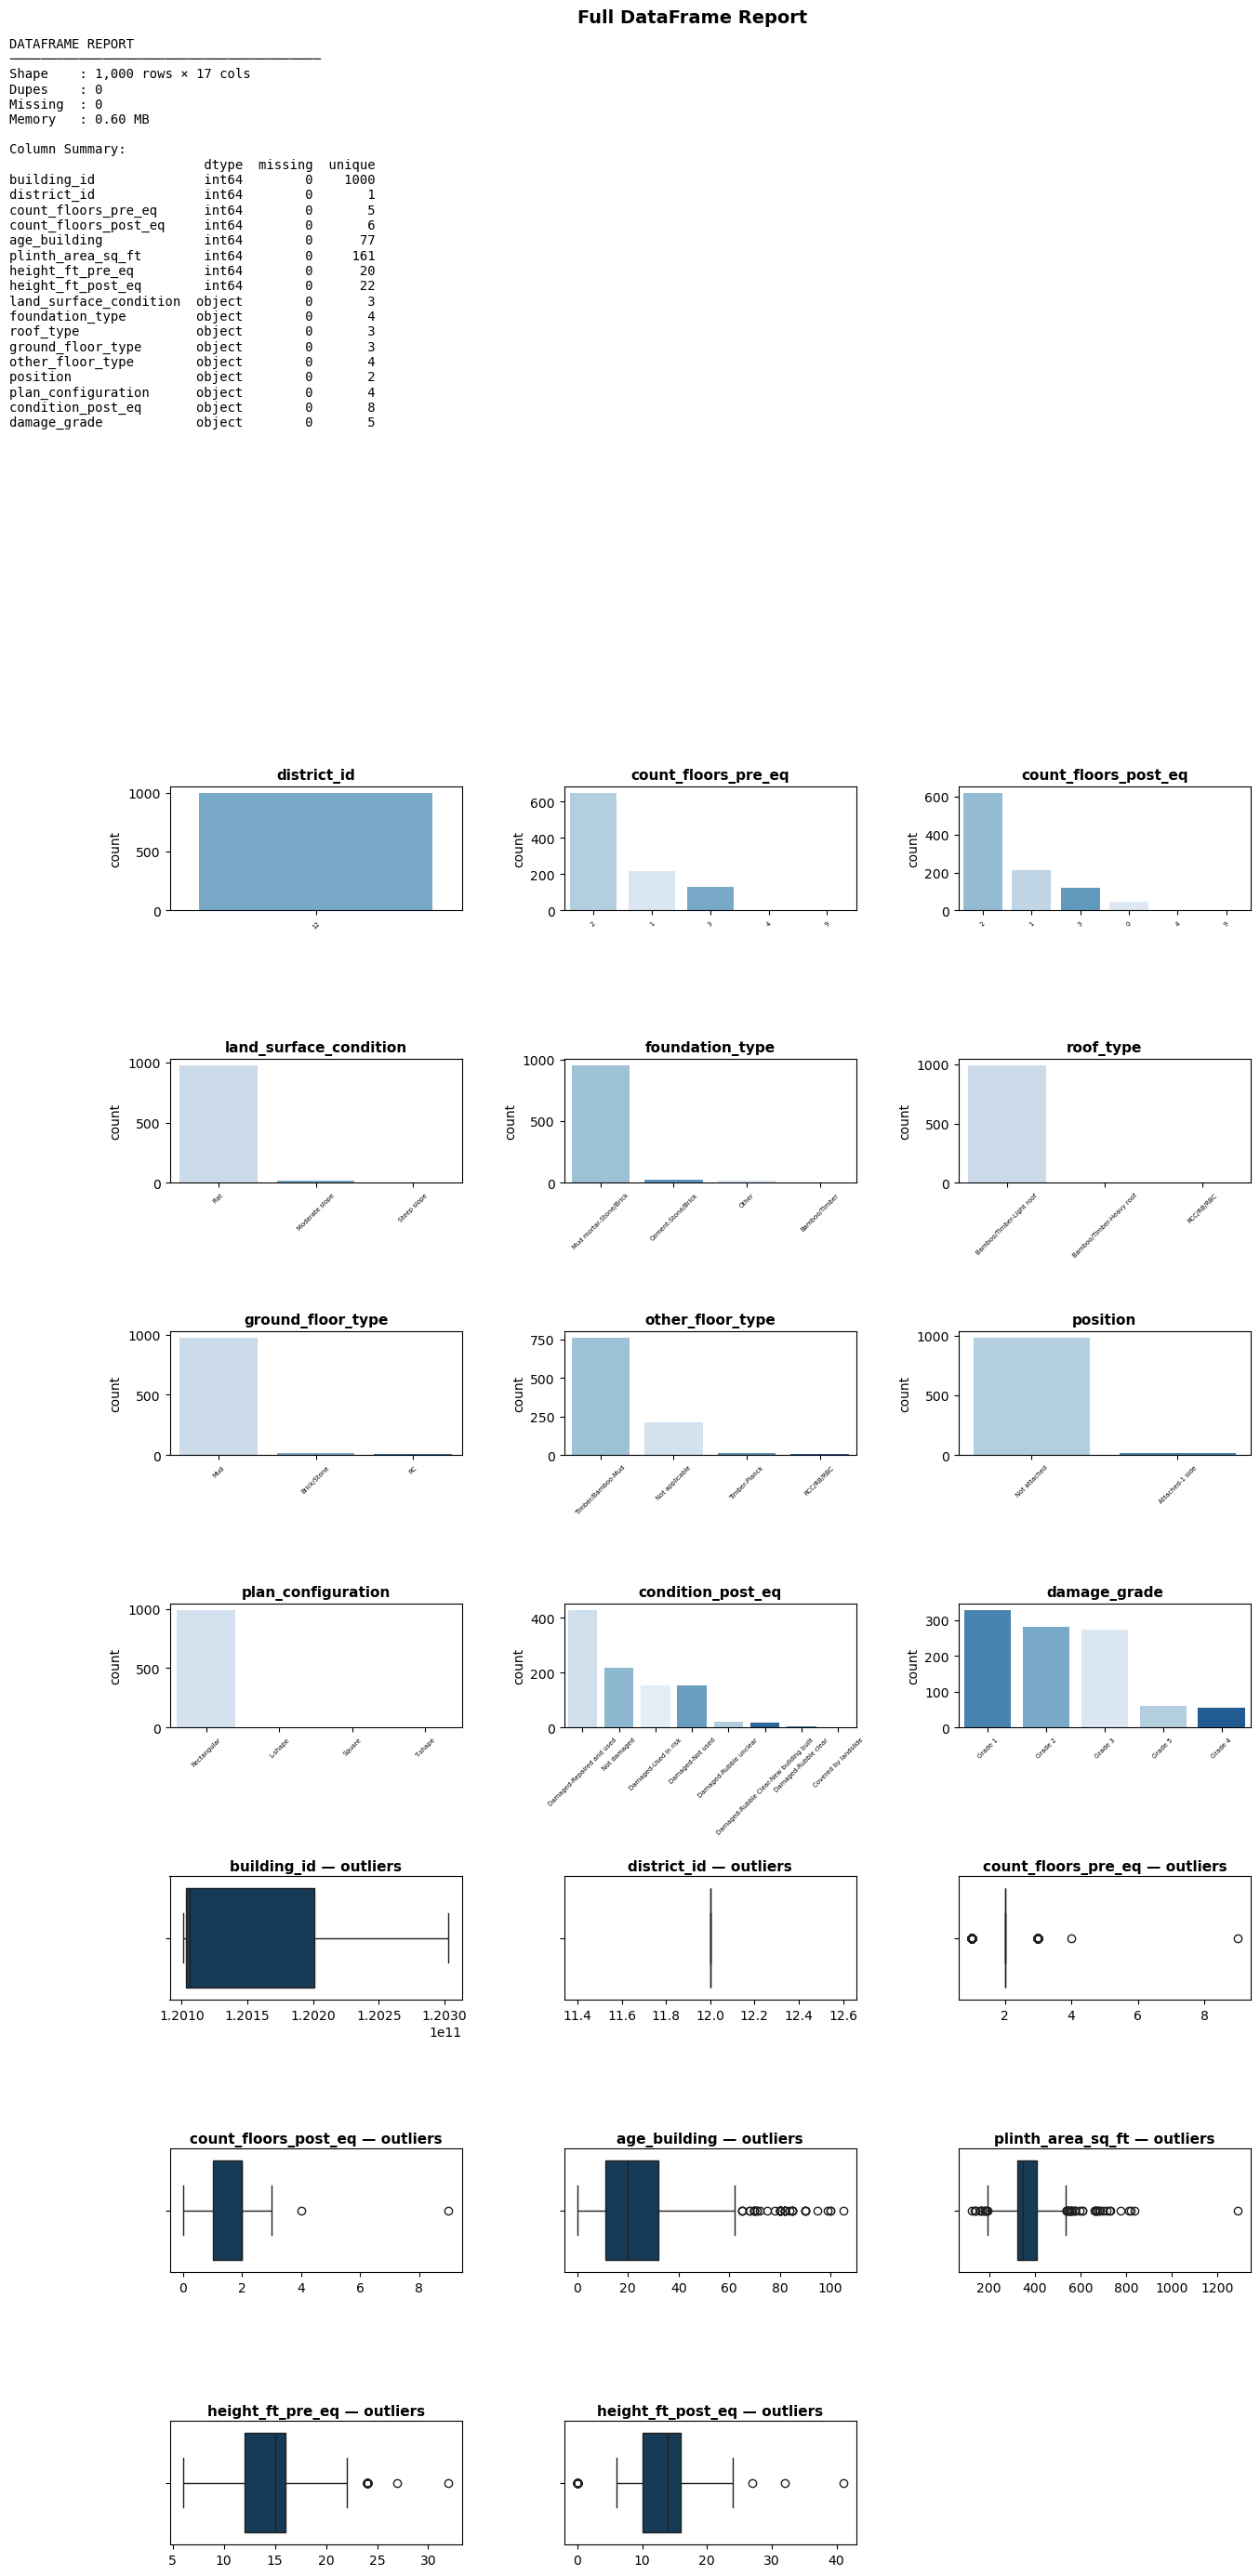

In [94]:
df_full_report(df)

In [96]:
df.head()

,building_id,district_id,count_floors_pre_eq,count_floors_post_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,height_ft_post_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,condition_post_eq,damage_grade
0,120101000011,12,1,1,9,288,9,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,Damaged-Used in risk,Grade 3
1,120101000021,12,1,1,15,364,9,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,Damaged-Repaired and used,Grade 5
2,120101000031,12,1,1,20,384,9,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,Damaged-Repaired and used,Grade 2
3,120101000041,12,1,1,20,312,9,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,Damaged-Repaired and used,Grade 2
4,120101000051,12,1,1,30,308,9,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,Damaged-Repaired and used,Grade 1


In [ ]:
def wrangle(path):
    #read
    df= pd.read_csv(path)
    
    df=df.dropna()
    # Create binary target column grade n >> n
    df["damage_grade"] = df["damage_grade"].str[-1].astype(int)
    df["severe_damage"] = (df["damage_grade"] > 3).astype(int)

    # Identify leaky columns
    drop_cols = [col for col in df.columns if "post_eq" in col]
    
    # Add high-cardinality / redundant column
    drop_cols.append("building_id")   
    # Drop old target
    drop_cols.append("damage_grade")
    # Drop multicollinearity column
    drop_cols.append("count_floors_pre_eq")
    
    # Drop columns
    df= df.drop(columns=drop_cols)
    
   
    return df

building_id is high high-cardinality 
(too many unique values, not useful for modeling)

In [100]:
df = wrangle("NepalEarhquakeDamage2015.csv")
df.head()

,district_id,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,severe_damage
0,12,9,288,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,0
1,12,15,364,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,1
2,12,20,384,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,0
3,12,20,312,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,0
4,12,30,308,9,Flat,Other,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,0


**dropping leaky features**

In other to predict earthquake damage we'll drop the variables related to post-earthquake and keep the variables related to pre-earthquake

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 762094 entries, 0 to 762105
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   district_id             762094 non-null  int64 
 1   age_building            762094 non-null  int64 
 2   plinth_area_sq_ft       762094 non-null  int64 
 3   height_ft_pre_eq        762094 non-null  int64 
 4   land_surface_condition  762094 non-null  object
 5   foundation_type         762094 non-null  object
 6   roof_type               762094 non-null  object
 7   ground_floor_type       762094 non-null  object
 8   other_floor_type        762094 non-null  object
 9   position                762094 non-null  object
 10  plan_configuration      762094 non-null  object
 11  severe_damage           762094 non-null  int32 
dtypes: int32(1), int64(4), object(7)
memory usage: 72.7+ MB


we will focus on **Ghorka district**, district_id=36

In [102]:
df["district_id"].value_counts().sort_values()

district_id
29    12644
12    39352
21    58612
22    60639
20    68749
28    77148
36    78074
23    88741
30    89122
31    90994
24    98019
Name: count, dtype: int64

<Axes: xlabel='district_id'>

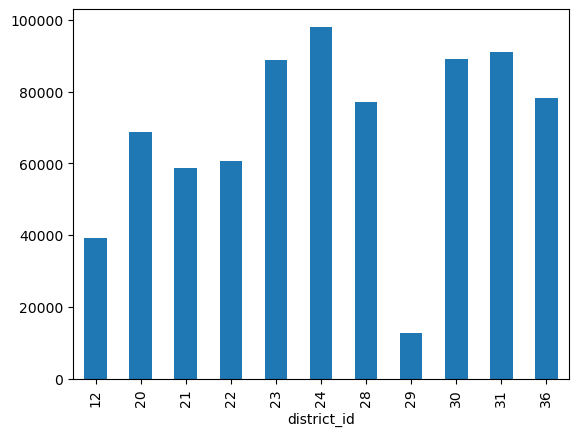

In [103]:
df["district_id"].value_counts().sort_index().plot(kind="bar")

In [104]:
df.shape

(762094, 12)

**encoding our target damage_grade to binary**

# Explore

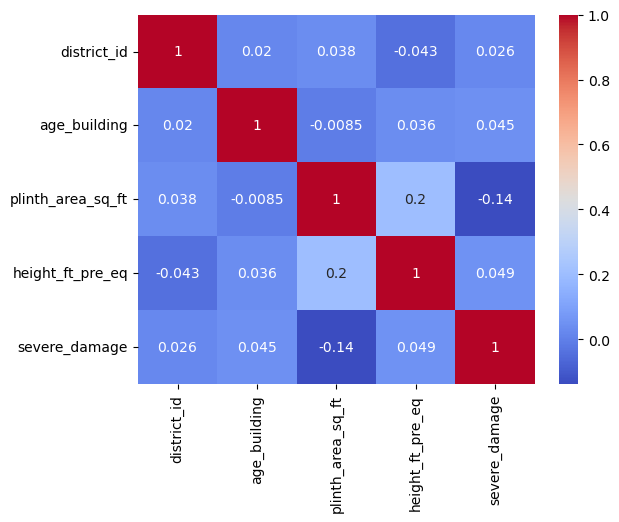

In [110]:
correlation = df.select_dtypes(include=["number"]).corr()
# Multicollinearity : count_floors_pre_eq = height_ft_pre_eq 

#drop one of them
sns.heatmap(correlation, annot=True, cmap="coolwarm");

**boxplot for distribution of height_ft_pre_eq**

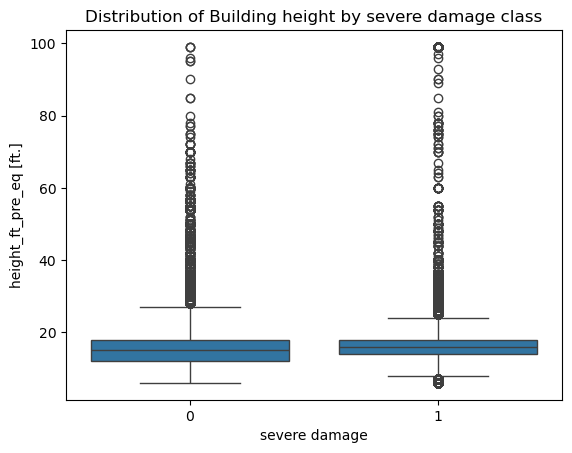

In [111]:
sns.boxplot(x="severe_damage", y="height_ft_pre_eq", data=df)
plt.xlabel("severe damage")
plt.ylabel("height_ft_pre_eq [ft.]")
plt.title("Distribution of Building height by severe damage class");
#(height_ft_pre_eq) does not appear to significantly affect (severe_damage).

around 65% of the buildings were severe damaged, (severe=1  positive class,   majority class)

around 35% of the buildings were not severe damaged, (severe=0  negative class,  minority class)

Text(0, 0.5, 'Percentage %')

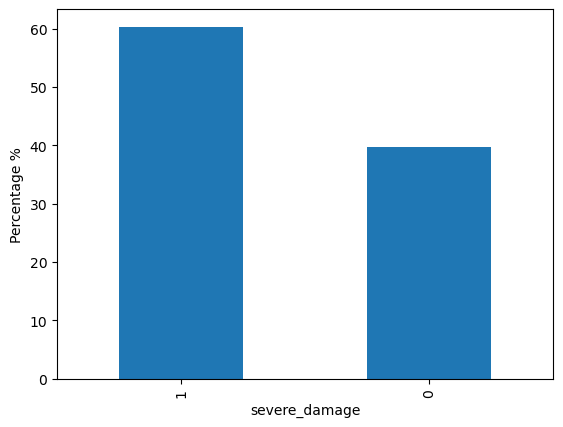

In [ ]:
df["severe_damage"].value_counts(normalize=True).plot(kind="bar");

Text(0, 0.5, 'value')

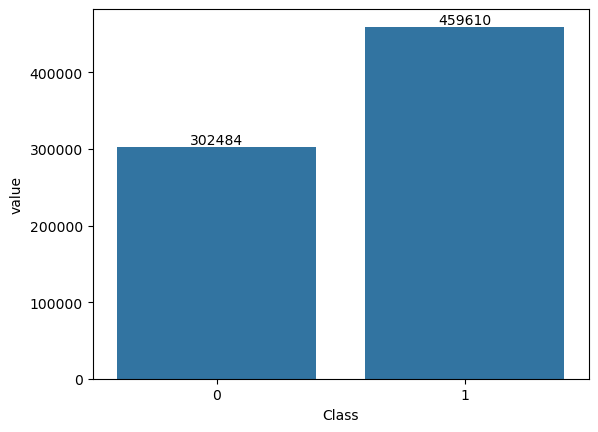

In [116]:
ax = sns.countplot(x="severe_damage", data=df)
ax.bar_label(ax.containers[0])
plt.xlabel("Class")
plt.ylabel("value")

In [122]:
majority_class_prop, minority_class_prop = round(df["severe_damage"].value_counts(normalize=True)*100,1)
print(majority_class_prop, minority_class_prop)

60.3 39.7


**Pivot table for foundation type**

In [135]:
foundation_pivot = pd.pivot_table(
    df,
    index="foundation_type",
    values="severe_damage",
    aggfunc="mean"
)

foundation_pivot.sort_values(by="severe_damage")

,severe_damage
foundation_type,
RC,0.038263
Bamboo/Timber,0.237855
Cement-Stone/Brick,0.296904
Other,0.510545
Mud mortar-Stone/Brick,0.685115


only 3% of the buildings that have the foundation type RC (reinforced concrete) suffered severe danmage

In [138]:
foundation_pivot["severe_damage"] = foundation_pivot["severe_damage"] *100

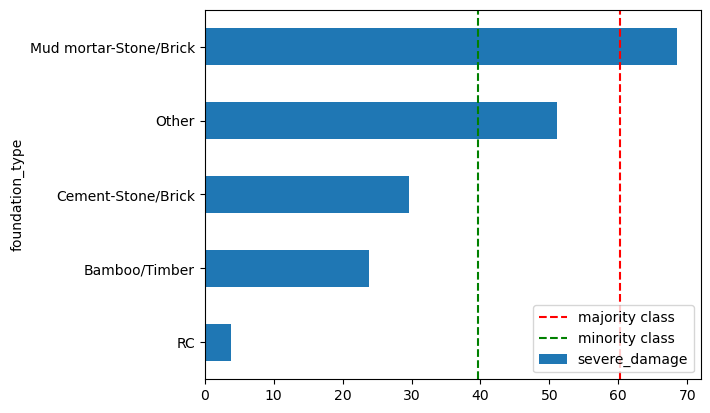

In [139]:
foundation_pivot.sort_values(by="severe_damage").plot(kind="barh", legend=None)

plt.axvline(
    majority_class_prop, linestyle="--", color="red", label="majority class"
)
plt.axvline(
    minority_class_prop, linestyle="--", color="green", label="minority class"
)
plt.legend(loc="lower right");

The diagram tells you: some types of foundations have higher than average damage (greater risk),
others have lower damage (safer).

the "RC" foundation type has a very low damage rate compared to average ⇒ safer buildings
"Mud Mortar-Stone/Brick" is much higher than average ⇒ unsafe type

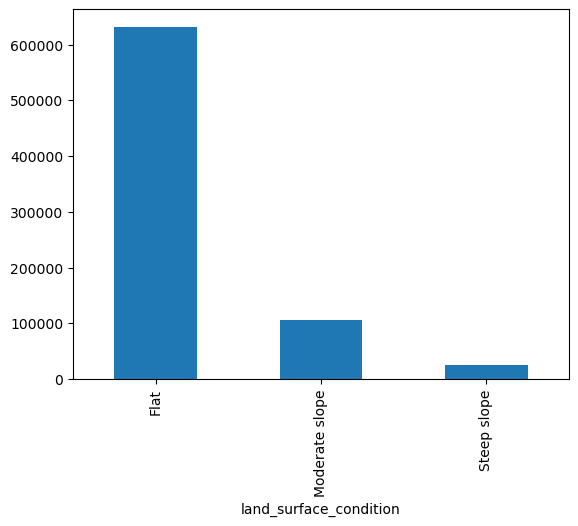

In [141]:
df["land_surface_condition"].value_counts().plot(kind="bar");

<Axes: xlabel='land_surface_condition'>

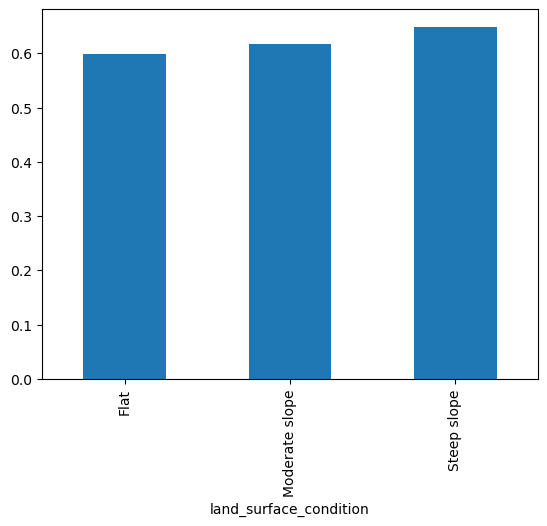

In [142]:
land_pivot = df.groupby("land_surface_condition")["severe_damage"].mean().sort_values()
land_pivot.plot(kind="bar")

"Buildings located on steep slopes are more likely to suffer severe damage during earthquakes. The damage rate increases from 59.9% on flat land to 64.8% on steep slopes, indicating terrain gradient is a relevant risk factor."


# Logistic Regression

**Split**

In [143]:
df.shape

(762094, 12)

In [144]:
target = "severe_damage"

X = df.drop(columns=target)
y=df[target]

In [145]:
X_train, X_test, y_train, y_test = train_test_split( 
                                            X, y, 
                                            test_size=0.2,
                                            random_state=42)

print("X_train_shape", X_train.shape)
print("X_test_shape", X_test.shape)
print("y_train_shape", y_train.shape)
print("y_test_shape", X_test.shape)

X_train_shape (609675, 11)
X_test_shape (152419, 11)
y_train_shape (609675,)
y_test_shape (152419, 11)


**Model build**

**Baseline**

In [ ]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 2))A

Baseline Accuracy: 0.6


**Iterate**

In [147]:
#Build model
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    LogisticRegression()
)

#Fit training model
model.fit(X_train, y_train)

c:\Users\Kyrollos\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Kyrollos\anaconda3\Lib\site-packages\sklearn\externals\_numpydoc\docscrape.py:420: UserWarning: Unknown section Example
  self[section] = content


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('onehotencoder', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['land_surface_condition', 'foundation_type', ...]"
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,use_cat_names,True


**Evaluate**

In [149]:
acc_train = model.score(X_train, y_train)
acc_test = model.score(X_test, y_test)


print("Training Accuracy:", round(acc_train, 2))
print("Test Accuracy:", round(acc_test, 2))

Training Accuracy: 0.72
Test Accuracy: 0.72


**communicate**

In [150]:
model.predict(X_train)[:5]

array([1, 1, 1, 1, 1])

In [151]:
#the column on the left represents the probability for our negative class [0], not severe damaged
#the column on the right reprsents the probability fo positive class [1], severe damaged
y_train_pred_proba = model.predict_proba(X_train)
print(y_train_pred_proba[:5])

[[0.28172864 0.71827136]
 [0.28114452 0.71885548]
 [0.24714099 0.75285901]
 [0.37574572 0.62425428]
 [0.26234847 0.73765153]]


In [152]:
features = model.named_steps["onehotencoder"].get_feature_names()
importances = model.named_steps["logisticregression"].coef_[0]

C:\Users\Kyrollos\AppData\Local\Temp\ipykernel_14548\1294114254.py:1: FutureWarning: `get_feature_names` is deprecated in all of sklearn. Use `get_feature_names_out` instead.
  features = model.named_steps["onehotencoder"].get_feature_names()


In [163]:
# odds ratio
odds_ratios = pd.Series(np.exp(importances), index=features).sort_values(ascending=False)
odds_ratios.head()

# head : Values > 1 indicate increased likelihood of severe damage
# Sorted to show the most influential risk factors at the top
# Mud mortar-Stone/Brick foundation shows the highest risk of severe damage.

# ascending=True : to get features decreased severe damage

foundation_type_Mud mortar-Stone/Brick    2.421961
ground_floor_type_Mud                     1.385913
ground_floor_type_Brick/Stone             1.360459
roof_type_Bamboo/Timber-Heavy roof        1.219667
other_floor_type_TImber/Bamboo-Mud        1.188377
dtype: float64

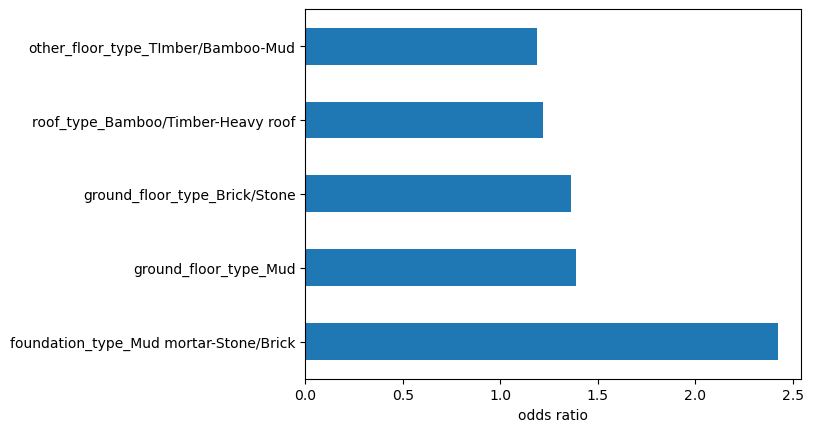

In [164]:
#features that are most associated with increase severe_damage
odds_ratios.head(5).plot(kind="barh")
plt.xlabel("odds ratio");

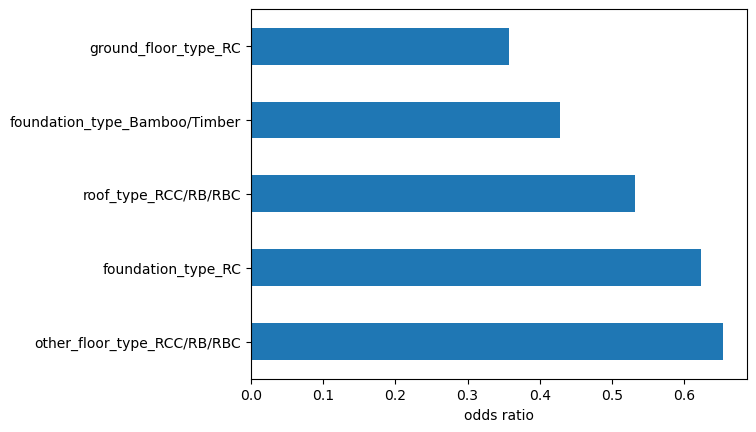

In [165]:
#features that are less associated with decrease severe_damage
odds_ratios.tail(5).plot(kind="barh")
plt.xlabel("odds ratio");

# Decision Tree

In [166]:
# train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
# validation set
X_train, X_val, y_train, y_val = train_test_split( X_train, y_train, test_size=0.20, random_state=42)

### **Build Model**

**Baseline**

In [167]:
y_train.value_counts(normalize=True)

severe_damage
1    0.603699
0    0.396301
Name: proportion, dtype: float64

In [168]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Baseline Accuracy:", round(acc_baseline, 2))

Baseline Accuracy: 0.6


**Iterate**

In [169]:
# Build model 
model_dt = make_pipeline(
    OrdinalEncoder(), DecisionTreeClassifier(random_state=42)
)
# Fit to training data
model_dt.fit(X_train, y_train)

c:\Users\Kyrollos\anaconda3\Lib\site-packages\sklearn\externals\_numpydoc\docscrape.py:420: UserWarning: Unknown section Example
  self[section] = content


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ordinalencoder', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,mapping,"[{'col': 'land_surface_condition', 'data_type': dtype('O'), 'mapping': Flat ...2 dtype: int64}, {'col': 'foundation_type', 'data_type': dtype('O'), 'mapping': Cement-Stone/...2 dtype: int64}, ...]"
,cols,"['land_surface_condition', 'foundation_type', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'


**validate**

In [170]:
acc_train = model_dt.score(X_train, y_train)
acc_val = model_dt.score(X_val, y_val)

print("Training Accuracy:", round(acc_train, 2))
print("Validation Accuracy:", round(acc_val, 2))

Training Accuracy: 0.97
Validation Accuracy: 0.71


In [172]:
# the model is overfitted, we need to set the correct depth
tree_depth = model_dt.named_steps["decisiontreeclassifier"].get_depth()
print("Tree depth", tree_depth)

Tree depth 53


### select the best max depth

In [173]:
depth_hyperparams = range(1, 20, 2) 

In [174]:
training_acc= []
validation_acc =[]
for d in depth_hyperparams:
    test_model  = make_pipeline(
        OrdinalEncoder(), 
        DecisionTreeClassifier(max_depth= d , random_state=42)
    )

    test_model.fit(X_train, y_train)
    training_acc.append(test_model.score(X_train, y_train))
    validation_acc.append(test_model.score(X_val,y_val))
    
print("Training Accuracy Scores:", training_acc[:3])
print("Validation Accuracy Scores:", validation_acc[:3])

Training Accuracy Scores: [0.6774121458153934, 0.7211526633042195, 0.7555131832533727]
Validation Accuracy Scores: [0.6773608889982368, 0.7224340837331366, 0.7558289252470578]


**Validation curve**

In [ ]:
#it seems that optimal max depth is 8

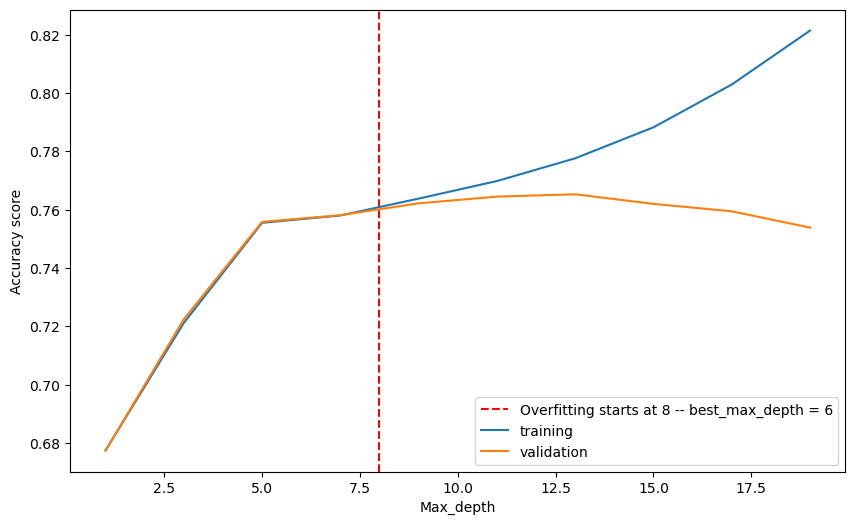

In [176]:
plt.figure(figsize=(10, 6))
for i in range(len(depth_hyperparams)):
    if training_acc[i]-validation_acc[i]>0.04:
        over_fit_depth=i
        best_max_depth=i-2

        plt.axvline(over_fit_depth ,color='red', linestyle='--',
                    label=f"Overfitting starts at {over_fit_depth} -- best_max_depth = {best_max_depth}" 
                   )


        break
plt.plot(depth_hyperparams, training_acc, label = "training")
plt.plot(depth_hyperparams, validation_acc, label = "validation")


plt.xlabel("Max_depth")
plt.ylabel("Accuracy score")
plt.legend();

**Evaluation**

In [177]:
final_model = make_pipeline(
        OrdinalEncoder(),
        DecisionTreeClassifier(max_depth=6, random_state=42)
    )

final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ordinalencoder', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,mapping,"[{'col': 'land_surface_condition', 'data_type': dtype('O'), 'mapping': Flat ...2 dtype: int64}, {'col': 'foundation_type', 'data_type': dtype('O'), 'mapping': Cement-Stone/...2 dtype: int64}, ...]"
,cols,"['land_surface_condition', 'foundation_type', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'


In [178]:
acc_train =  final_model.score(X_train, y_train)
acc_val = final_model.score(X_val, y_val)

print("Training Accuracy:", round(acc_train, 2))
print("Validation Accuracy:", round(acc_val, 2))

Training Accuracy: 0.76
Validation Accuracy: 0.76


In [179]:
test_acc = final_model.score(X_test, y_test)
print("test accuracy:", round(test_acc, 2))

test accuracy: 0.76


**Communicate**

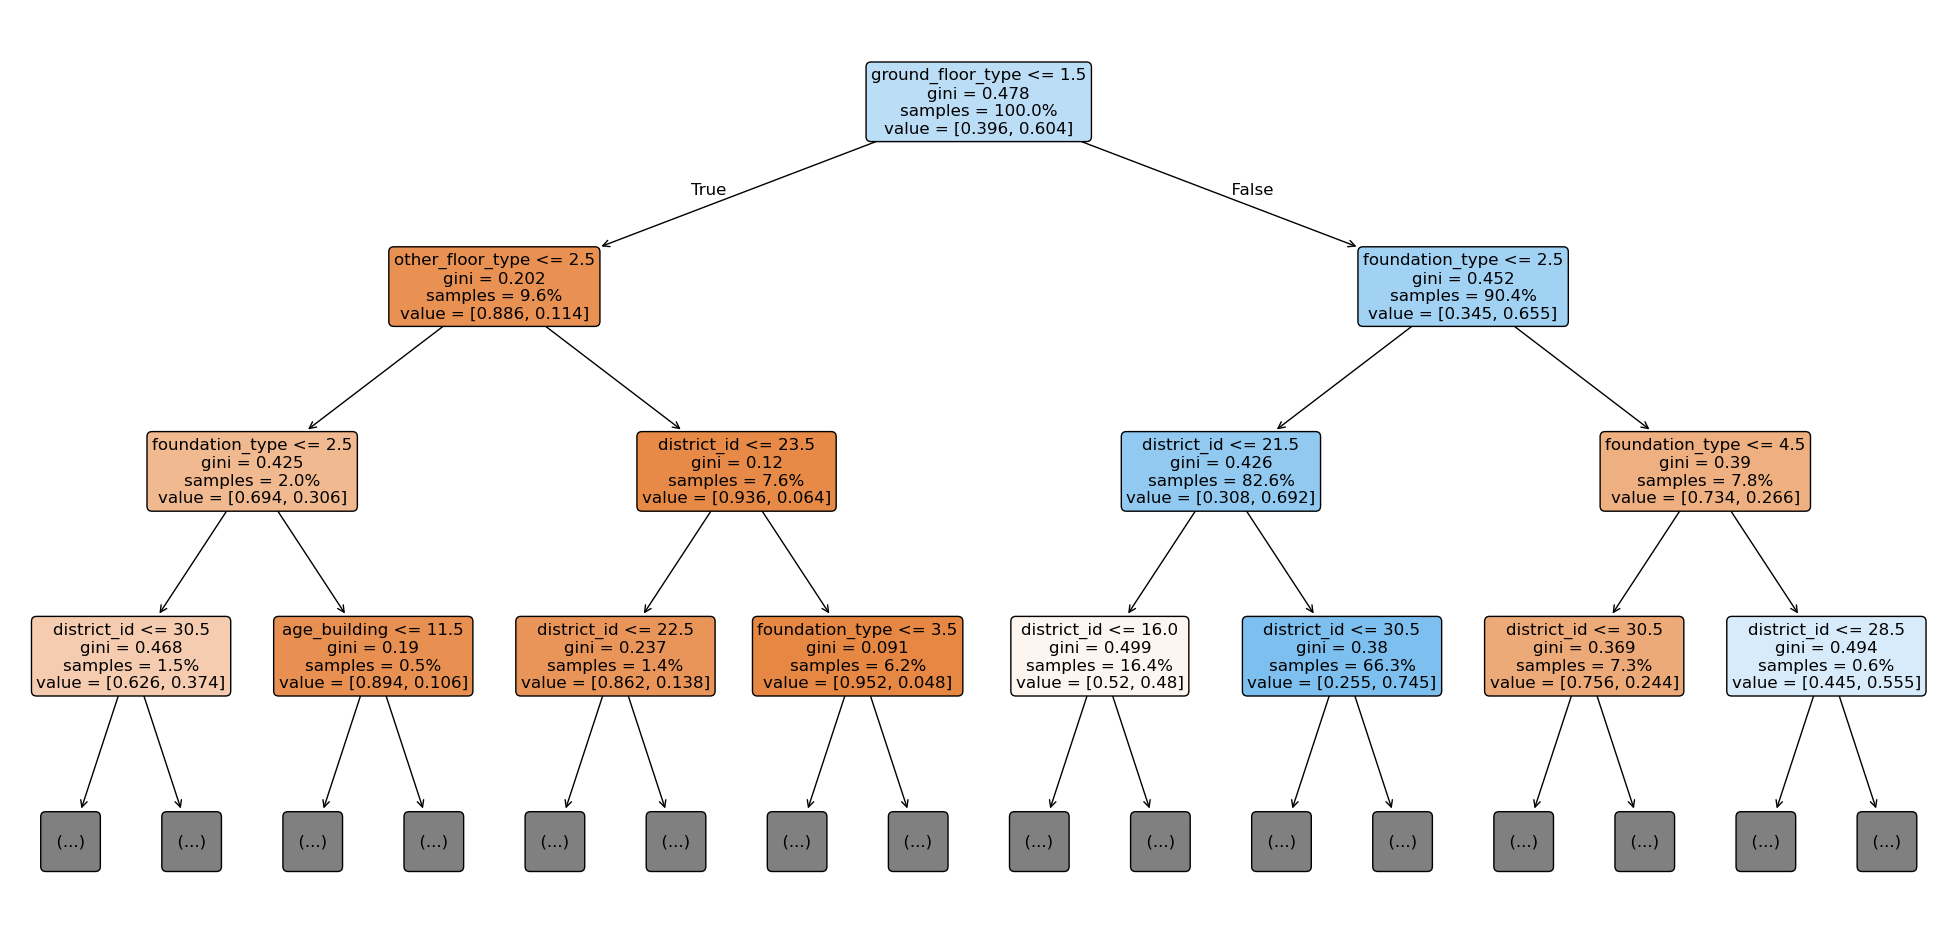

In [180]:
# Create larger figure
fig, ax = plt.subplots(figsize=(25, 12))
# Plot tree
plot_tree(
    decision_tree=final_model.named_steps["decisiontreeclassifier"],
    feature_names=X_train.columns,
    filled=True,  # Color leaf with class
    rounded=True,  # Round leaf edges
    proportion=True,  # Display proportion of classes in leaf
    max_depth=3,  # Only display first 3 levels
    fontsize=12,  # Enlarge font
    ax=ax,  # Place in figure axis
);

In [181]:
features = X_train.columns
importances = final_model.named_steps["decisiontreeclassifier"].feature_importances_

print("Features:", features[:3])
print("Importances:", importances[:3])

Features: Index(['district_id', 'age_building', 'plinth_area_sq_ft'], dtype='object')
Importances: [0.42615237 0.01833435 0.00191748]


In [182]:
feat_imp = pd.Series(importances,index=features)
feat_imp.head()

district_id               0.426152
age_building              0.018334
plinth_area_sq_ft         0.001917
height_ft_pre_eq          0.001876
land_surface_condition    0.001407
dtype: float64

 Create a horizontal bar chart with all the features in feat_imp. Be sure to label your x-axis **"Gini Importances"**

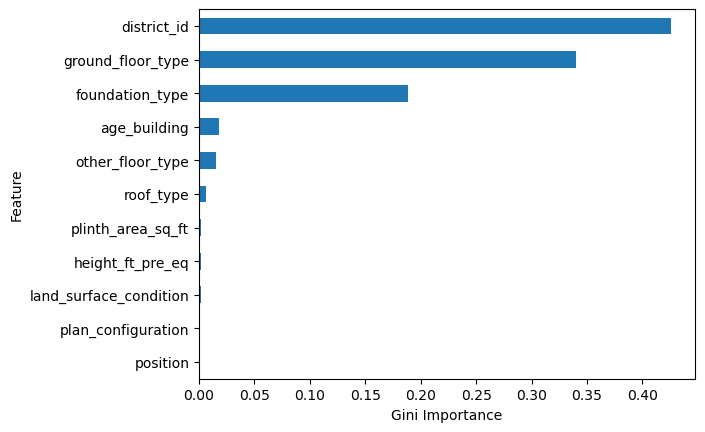

In [183]:
feat_imp.sort_values().plot(kind="barh")
plt.xlabel("Gini Importance")
plt.ylabel("Feature");

In [ ]:
# District ID, ground floor type, and foundation type are the most influential features according to Gini importance. 
# This suggests that location and construction materials play a key role in severe damage prediction."

**This project was possible thanks to the lessons from Worldquant university data science lab**

Kyrollos Ashraf